In [1]:
import os
import gc
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub


In [2]:
SEED = 42
IMG_SIZE = (224, 224)
AE_BATCH_SIZE = 32
LATENT_DIM = 256

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Use both Kaggle T4 GPUs
strategy = tf.distribute.MirroredStrategy()

# T4 GPUs perform convolution faster with mixed precision
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("GPUs being used:", strategy.num_replicas_in_sync)
print("Precision policy:", tf.keras.mixed_precision.global_policy())
print("DeepSMOTE image size:", IMG_SIZE)
print("Latent dimensions:", LATENT_DIM)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPUs being used: 2
Precision policy: <DTypePolicy "mixed_float16">
DeepSMOTE image size: (224, 224)
Latent dimensions: 256


I0000 00:00:1789459011.456199      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789459011.459007      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
DATASET_PATH = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

IMAGE_DIR = DATASET_PATH / "combined_images"

print("Dataset path:", DATASET_PATH)
print("Image folder:", IMAGE_DIR)
print("Image folder exists:", IMAGE_DIR.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, label in class_mapping.items():
    class_folder = IMAGE_DIR / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df))
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Training: 30800
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def load_mri(file_path, label):
    image_bytes = tf.io.read_file(file_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )
    image.set_shape([None, None, 1])

    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )
    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear"
    )

    return image, tf.cast(label, tf.int32)


def make_image_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].to_numpy(),
        dataframe["label"].to_numpy()
    ))

    # Shuffle file paths before loading images to save RAM
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_mri,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        AE_BATCH_SIZE,
        drop_remainder=False
    )

    return dataset.prefetch(AUTOTUNE)


train_image_ds = make_image_dataset(
    train_df,
    training=True
)

validation_image_ds = make_image_dataset(
    validation_df
)

test_image_ds = make_image_dataset(
    test_df
)

sample_images, sample_labels = next(iter(train_image_ds))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Pixel range:",
      float(tf.reduce_min(sample_images)),
      "to",
      float(tf.reduce_max(sample_images)))
print("First labels:", sample_labels[:10].numpy())

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Pixel range: 0.0 to 1.0
First labels: [0 1 0 0 1 1 0 1 0 1]


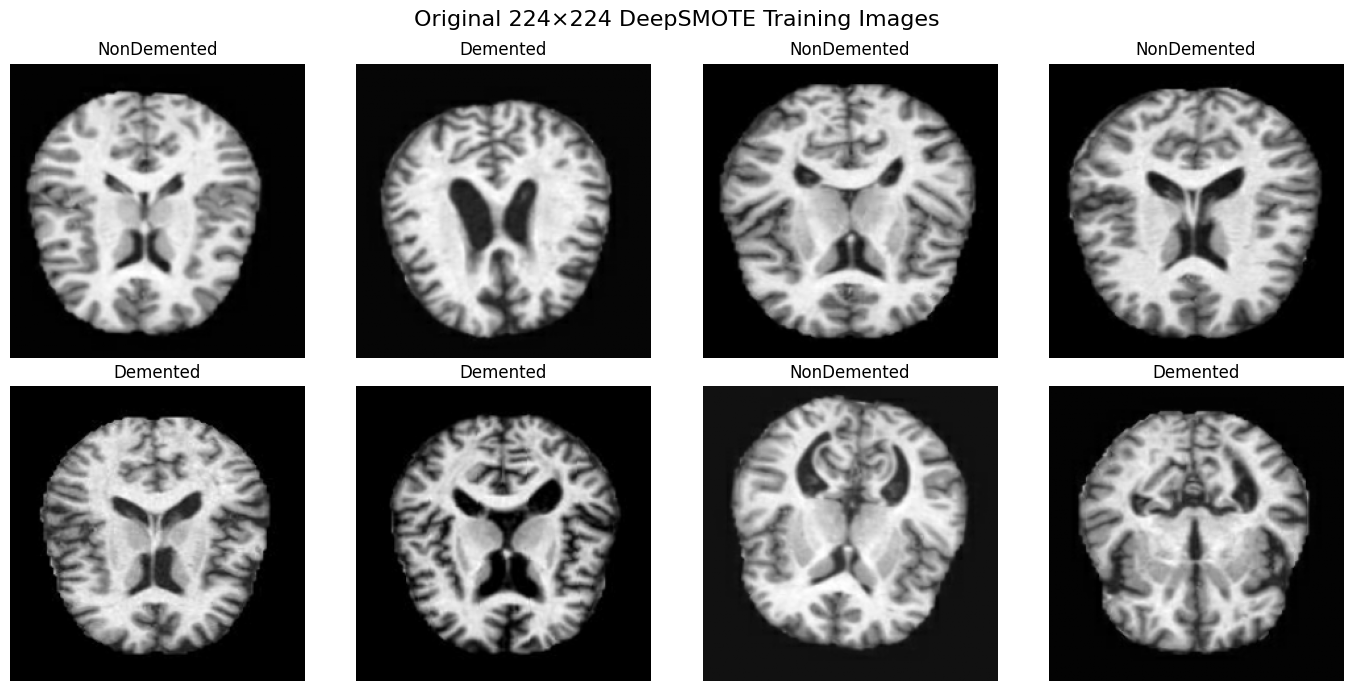

In [7]:
class_names = {
    0: "NonDemented",
    1: "Demented"
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for axis, image, label in zip(
    axes.flat,
    sample_images[:8],
    sample_labels[:8]
):
    axis.imshow(
        tf.squeeze(image),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axis.set_title(class_names[int(label)])
    axis.axis("off")

plt.suptitle(
    "Original 224×224 DeepSMOTE Training Images",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [8]:
AE_EPOCHS = 100
AE_PATIENCE = 8
AE_LEARNING_RATE = 2e-4

LATENT_DIM = 300
RECONSTRUCTION_WEIGHT = 1.0
PENALTY_WEIGHT = 1.0

print("Method: Original-style DeepSMOTE baseline")
print("Image size:", IMG_SIZE)
print("Batch size:", AE_BATCH_SIZE)
print("Latent dimensions:", LATENT_DIM)
print("Maximum epochs:", AE_EPOCHS)
print("Early-stopping patience:", AE_PATIENCE)
print("Learning rate:", AE_LEARNING_RATE)
print("Reconstruction loss: MSE")
print("Reconstruction weight:", RECONSTRUCTION_WEIGHT)
print("Same-class penalty: MSE")
print("Penalty weight:", PENALTY_WEIGHT)

Method: Original-style DeepSMOTE baseline
Image size: (224, 224)
Batch size: 32
Latent dimensions: 300
Maximum epochs: 100
Early-stopping patience: 8
Learning rate: 0.0002
Reconstruction loss: MSE
Reconstruction weight: 1.0
Same-class penalty: MSE
Penalty weight: 1.0


In [9]:
tf.keras.backend.clear_session()

def build_encoder():
    inputs = tf.keras.Input(
        shape=(224, 224, 1),
        name="encoder_input"
    )

    x = inputs

    for layer_number, filters in enumerate(
        [64, 128, 256, 512, 512]
    ):
        x = tf.keras.layers.Conv2D(
            filters,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.02
            ),
            name=f"encoder_conv_{layer_number + 1}"
        )(x)

        if layer_number > 0:
            x = tf.keras.layers.BatchNormalization(
                name=f"encoder_bn_{layer_number + 1}"
            )(x)

        x = tf.keras.layers.LeakyReLU(
            negative_slope=0.2,
            name=f"encoder_leakyrelu_{layer_number + 1}"
        )(x)

    x = tf.keras.layers.Flatten(name="encoder_flatten")(x)

    latent = tf.keras.layers.Dense(
        LATENT_DIM,
        activation=None,
        dtype="float32",
        name="latent_vector"
    )(x)

    return tf.keras.Model(
        inputs,
        latent,
        name="DeepSMOTE_Encoder"
    )


with strategy.scope():
    encoder = build_encoder()

print("Encoder output shape:", encoder.output_shape)
print("Encoder parameters:", encoder.count_params())

encoder.summary()

Encoder output shape: (None, 300)
Encoder parameters: 14480172


Model: "DeepSMOTE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 112, 112, 64)   │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_1 (LeakyReLU) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 56, 56, 128)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_2                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_2 (LeakyReLU) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 28, 28, 256)    │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_3                    │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_3 (LeakyReLU) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 14, 14, 512)    │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_4                    │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_4 (LeakyReLU) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_5 (Conv2D)         │ (None, 7, 7, 512)      │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_5                    │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_5 (LeakyReLU) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_flatten (Flatten)       │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 300)            │     7,526,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,480,172 (55.24 MB)

 Trainable params: 14,477,356 (55.23 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [10]:
def build_decoder():
    latent_inputs = tf.keras.Input(
        shape=(LATENT_DIM,),
        name="decoder_latent_input"
    )

    x = tf.keras.layers.Dense(
        7 * 7 * 512,
        use_bias=False,
        name="decoder_dense"
    )(latent_inputs)

    x = tf.keras.layers.Reshape(
        (7, 7, 512),
        name="decoder_reshape"
    )(x)

    decoder_filters = [512, 256, 128, 64]

    for layer_number, filters in enumerate(decoder_filters):
        x = tf.keras.layers.Conv2DTranspose(
            filters,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.02
            ),
            name=f"decoder_transpose_{layer_number + 1}"
        )(x)

        x = tf.keras.layers.BatchNormalization(
            name=f"decoder_bn_{layer_number + 1}"
        )(x)

        x = tf.keras.layers.ReLU(
            name=f"decoder_relu_{layer_number + 1}"
        )(x)

    outputs = tf.keras.layers.Conv2DTranspose(
        1,
        kernel_size=4,
        strides=2,
        padding="same",
        activation="tanh",
        dtype="float32",
        kernel_initializer=tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=0.02
        ),
        name="decoder_output"
    )(x)

    return tf.keras.Model(
        latent_inputs,
        outputs,
        name="DeepSMOTE_Decoder"
    )


with strategy.scope():
    decoder = build_decoder()

print("Decoder input shape:", decoder.input_shape)
print("Decoder output shape:", decoder.output_shape)
print("Decoder parameters:", decoder.count_params())

decoder.summary()

Decoder input shape: (None, 300)
Decoder output shape: (None, 224, 224, 1)
Decoder parameters: 14478081


Model: "DeepSMOTE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_latent_input            │ (None, 300)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 25088)          │     7,526,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_reshape (Reshape)       │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_1             │ (None, 14, 14, 512)    │     4,194,304 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_1 (ReLU)           │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_2             │ (None, 28, 28, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_2                    │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_2 (ReLU)           │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_3             │ (None, 56, 56, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_3                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_3 (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_4             │ (None, 112, 112, 64)   │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_4                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_4 (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 224, 224, 1)    │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,478,081 (55.23 MB)

 Trainable params: 14,476,161 (55.22 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [11]:
def make_repeated_class_dataset(class_dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        class_dataframe["filepath"].to_numpy(),
        class_dataframe["label"].to_numpy()
    ))

    dataset = dataset.shuffle(
        buffer_size=len(class_dataframe),
        seed=SEED,
        reshuffle_each_iteration=True
    )

    dataset = dataset.repeat()

    dataset = dataset.map(
        load_mri,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        AE_BATCH_SIZE,
        drop_remainder=True
    )

    return dataset.prefetch(AUTOTUNE)


class_0_df = train_df[train_df["label"] == 0]
class_1_df = train_df[train_df["label"] == 1]

class_0_penalty_ds = make_repeated_class_dataset(class_0_df)
class_1_penalty_ds = make_repeated_class_dataset(class_1_df)

# Each selected batch comes entirely from one class
penalty_ds = tf.data.Dataset.sample_from_datasets(
    [class_0_penalty_ds, class_1_penalty_ds],
    weights=[0.5, 0.5],
    seed=SEED
)

# First item: normal reconstruction batch
# Second item: same-class penalty batch
deep_smote_train_ds = tf.data.Dataset.zip((
    train_image_ds,
    penalty_ds
))

normal_batch, penalty_batch = next(
    iter(deep_smote_train_ds)
)

normal_images, normal_labels = normal_batch
penalty_images, penalty_labels = penalty_batch

print("Normal image batch:", normal_images.shape)
print("Normal batch classes:",
      np.unique(normal_labels.numpy()))

print("Penalty image batch:", penalty_images.shape)
print("Penalty batch classes:",
      np.unique(penalty_labels.numpy()))

print("Class 0 training images:", len(class_0_df))
print("Class 1 training images:", len(class_1_df))

Normal image batch: (32, 224, 224, 1)
Normal batch classes: [0 1]
Penalty image batch: (32, 224, 224, 1)
Penalty batch classes: [0]
Class 0 training images: 8960
Class 1 training images: 21840


In [12]:
class DeepSMOTETrainer(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__(name="DeepSMOTE_Trainer")

        self.encoder = encoder
        self.decoder = decoder

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.penalty_tracker = tf.keras.metrics.Mean(
            name="penalty_loss"
        )

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.reconstruction_tracker,
            self.penalty_tracker
        ]

    def scale_images(self, images):
        # Dataset range 0–1 → tanh-compatible range -1–1
        images = tf.cast(images, tf.float32)
        return (images * 2.0) - 1.0

    def call(self, images, training=False):
        images = self.scale_images(images)
        latent = self.encoder(images, training=training)
        return self.decoder(latent, training=training)

    def train_step(self, data):
        normal_batch, penalty_batch = data
        normal_images, _ = normal_batch
        penalty_images, _ = penalty_batch

        normal_images = self.scale_images(normal_images)
        penalty_images = self.scale_images(penalty_images)

        with tf.GradientTape() as tape:
            # Standard reconstruction
            normal_latent = self.encoder(
                normal_images,
                training=True
            )
            reconstructed = self.decoder(
                normal_latent,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.square(normal_images - reconstructed)
            )

            # Same-class DeepSMOTE penalty
            penalty_latent = self.encoder(
                penalty_images,
                training=True
            )

            permutation = tf.random.shuffle(
                tf.range(tf.shape(penalty_latent)[0])
            )

            permuted_latent = tf.gather(
                penalty_latent,
                permutation
            )
            permuted_targets = tf.gather(
                penalty_images,
                permutation
            )

            penalty_reconstruction = self.decoder(
                permuted_latent,
                training=True
            )

            penalty_loss = tf.reduce_mean(
                tf.square(
                    permuted_targets -
                    penalty_reconstruction
                )
            )

            total_loss = (
                RECONSTRUCTION_WEIGHT * reconstruction_loss +
                PENALTY_WEIGHT * penalty_loss
            )

            # Required for mixed-float16 training
            scaled_loss = self.optimizer.scale_loss(total_loss)

        trainable_variables = (
            self.encoder.trainable_variables +
            self.decoder.trainable_variables
        )

        gradients = tape.gradient(
            scaled_loss,
            trainable_variables
        )

        self.optimizer.apply_gradients(
            zip(gradients, trainable_variables)
        )

        self.loss_tracker.update_state(total_loss)
        self.reconstruction_tracker.update_state(
            reconstruction_loss
        )
        self.penalty_tracker.update_state(penalty_loss)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_tracker.result(),
            "penalty_loss": self.penalty_tracker.result()
        }

    def test_step(self, data):
        images, _ = data
        images = self.scale_images(images)

        latent = self.encoder(images, training=False)
        reconstructed = self.decoder(latent, training=False)

        reconstruction_loss = tf.reduce_mean(
            tf.square(images - reconstructed)
        )

        self.loss_tracker.update_state(reconstruction_loss)
        self.reconstruction_tracker.update_state(
            reconstruction_loss
        )
        self.penalty_tracker.update_state(0.0)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_tracker.result(),
            "penalty_loss": self.penalty_tracker.result()
        }


with strategy.scope():
    deep_smote_model = DeepSMOTETrainer(
        encoder,
        decoder
    )

    deep_smote_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=AE_LEARNING_RATE
        )
    )

preview_output = deep_smote_model(
    sample_images[:2],
    training=False
)

print("Untrained reconstruction shape:",
      preview_output.shape)
print("Output range:",
      float(tf.reduce_min(preview_output)),
      "to",
      float(tf.reduce_max(preview_output)))

Untrained reconstruction shape: (2, 224, 224, 1)
Output range: -0.0002355179312871769 to 0.0001730246003717184


In [13]:
generator_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=AE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/deepsmote_baseline_best.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

generator_history = deep_smote_model.fit(
    deep_smote_train_ds,
    validation_data=validation_image_ds,
    epochs=AE_EPOCHS,
    callbacks=generator_callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

KeyboardInterrupt: 